In [ ]:
# !pip3 install pandas numpy matplotlib scipy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (9, 5)

## Configuration

In [2]:
NAME     = "t_1500_3000"   # scheme name — matches the filenames
NODE_IDS = [0, 1, 2, 3, 4] # node IDs present in the experiment
DATA_DIR = "./data"

## Load node logs

In [3]:
traces = {}
for nid in NODE_IDS:
    path = f"{DATA_DIR}/node_{nid}_{NAME}.csv"
    df = pd.read_csv(path)
    df = df.sort_values("timestamp_usec").reset_index(drop=True)
    df["timestamp_sec"] = df["timestamp_usec"] / 1e6
    traces[nid] = df
    print(f"Node {nid}: {len(df)} events")

# Combine into one dataframe for cross-node queries
all_events = pd.concat(traces.values(), ignore_index=True).sort_values("timestamp_usec").reset_index(drop=True)
all_events.head(10)

Node 0: 4428 events
Node 1: 4319 events
Node 2: 4890 events
Node 3: 4161 events
Node 4: 4277 events


,node_id,timestamp_usec,event,term,leader_id,value,timestamp_sec
0,4,9192143062,starting,-1,-1,-1,9192.143062
1,4,9192146348,timeout,0,-1,0,9192.146348
2,4,9193036488,became_candidate,1,-1,0,9193.036488
3,4,9193039423,became_follower,2,0,0,9193.039423
4,4,9193041950,became_follower,3,0,0,9193.041950
5,4,9193550302,heartbeat,3,0,500951,9193.550302
6,4,9194051368,heartbeat,3,0,501083,9194.051368
7,4,9194552347,heartbeat,3,0,500966,9194.552347
8,4,9195134497,heartbeat,3,0,582166,9195.134497
9,4,9195553286,heartbeat,3,0,418758,9195.553286


## Identify crash terms

An `intentional_crash` event in term **T** means we should look for the next leader election in term **T+1**.
Detection time = `became_leader (T+1)` − `last heartbeat before timeout in term T` on the node that detected the crash.

In [4]:
crash_events = all_events[all_events["event"] == "intentional_crash"].copy()
print(f"Found {len(crash_events)} intentional crashes")
crash_events[["node_id", "timestamp_sec", "term", "leader_id"]]

Found 106 intentional crashes


,node_id,timestamp_sec,term,leader_id
125,4,9247.760271,4,-1
369,0,9292.796888,3,-1
596,3,9322.988299,6,-1
1012,1,9373.959401,5,-1
1227,0,9404.681054,7,-1
...,...,...,...,...
21073,0,12173.353636,117,-1
21524,3,12241.821267,121,-1
21549,4,12250.099757,122,-1
21561,2,12253.451442,120,-1


In [5]:
MAX_TERM_SEARCH = 10

records = []

for _, crash in crash_events.iterrows():
    crash_term = int(crash["term"])

    # --- Find became_leader in T+1, T+2, ... up to MAX_TERM_SEARCH ---
    leader_row    = None
    election_term = None
    for offset in range(1, MAX_TERM_SEARCH + 1):
        candidate_term = crash_term + offset
        leader_rows = all_events[
            (all_events["event"] == "became_leader") &
            (all_events["term"]  == candidate_term)
        ]
        if not leader_rows.empty:
            election_term = candidate_term
            leader_row = leader_rows.sort_values("timestamp_usec").iloc[0]
            if offset > 1:
                print(f"  [INFO] Crash term {crash_term}: leader found at term {election_term} "
                      f"(after {offset - 1} failed election(s))")
            break

    if leader_row is None:
        print(f"  [SKIP] Crash term {crash_term}: no became_leader within {MAX_TERM_SEARCH} terms — skipping")
        continue

    new_leader_id = int(leader_row["node_id"])
    t_leader      = leader_row["timestamp_sec"]

    # --- Find the last heartbeat before the timeout on the new leader's node ---
    # Accept timeouts in any term between crash_term and election_term (inclusive)
    node_trace = traces[new_leader_id]

    timeout_rows = node_trace[
        (node_trace["event"] == "timeout") &
        (node_trace["term"].between(crash_term, election_term))
    ]

    if timeout_rows.empty:
        print(f"  [WARN] No timeout found on node {new_leader_id} for terms {crash_term}->{election_term}")
        continue

    # Use the first timeout that precedes became_leader
    timeout_row = timeout_rows[
        timeout_rows["timestamp_usec"] < leader_row["timestamp_usec"]
    ].sort_values("timestamp_usec").iloc[0]

    t_timeout = timeout_row["timestamp_sec"]

    # Last heartbeat strictly before that first timeout
    hb_before = node_trace[
        (node_trace["event"]         == "heartbeat") &
        (node_trace["timestamp_usec"] < timeout_row["timestamp_usec"])
    ]

    if hb_before.empty:
        print(f"  [WARN] No heartbeat before timeout on node {new_leader_id} for crash term {crash_term}")
        continue

    last_hb   = hb_before.sort_values("timestamp_usec").iloc[-1]
    t_last_hb = last_hb["timestamp_sec"]

    detection_time_sec = t_leader - t_last_hb

    records.append({
        "crash_term":       crash_term,
        "election_term":    election_term,
        "failed_elections": election_term - crash_term - 1,
        "new_leader":       new_leader_id,
        "t_last_heartbeat": t_last_hb,
        "t_timeout":        t_timeout,
        "t_became_leader":  t_leader,
        "detection_sec":    detection_time_sec,
        "detection_ms":     detection_time_sec * 1000,
    })

results = pd.DataFrame(records)
print(f"\nSuccessfully measured {len(results)} crash-detection events")
results


  [INFO] Crash term 15: leader found at term 17 (after 1 failed election(s))
  [INFO] Crash term 26: leader found at term 28 (after 1 failed election(s))
  [INFO] Crash term 32: leader found at term 34 (after 1 failed election(s))
  [INFO] Crash term 36: leader found at term 38 (after 1 failed election(s))
  [INFO] Crash term 43: leader found at term 45 (after 1 failed election(s))
  [INFO] Crash term 54: leader found at term 56 (after 1 failed election(s))
  [INFO] Crash term 70: leader found at term 72 (after 1 failed election(s))
  [INFO] Crash term 73: leader found at term 76 (after 2 failed election(s))
  [INFO] Crash term 82: leader found at term 84 (after 1 failed election(s))
  [INFO] Crash term 90: leader found at term 93 (after 2 failed election(s))
  [INFO] Crash term 94: leader found at term 96 (after 1 failed election(s))
  [INFO] Crash term 108: leader found at term 110 (after 1 failed election(s))

Successfully measured 106 crash-detection events


,crash_term,election_term,failed_elections,new_leader,t_last_heartbeat,t_timeout,t_became_leader,detection_sec,detection_ms
0,4,5,0,1,9346.112734,9348.115269,9348.349589,2.236855,2236.855
1,3,4,0,4,9219.568743,9221.998114,9222.507469,2.938726,2938.726
2,6,7,0,0,9376.893403,9378.518158,9378.754719,1.861316,1861.316
3,5,6,0,3,9294.960181,9297.070143,9297.368195,2.408014,2408.014
4,7,8,0,2,9394.808546,9396.432429,9397.078520,2.269974,2269.974
...,...,...,...,...,...,...,...,...,...
101,117,118,0,4,12100.128029,12101.820940,12102.342629,2.214600,2214.600
102,121,122,0,4,12222.768715,12224.541029,12224.777496,2.008781,2008.781
103,122,123,0,3,12269.305556,12271.634600,12271.840769,2.535213,2535.213
104,120,121,0,3,12209.477038,12211.332109,12211.683862,2.206824,2206.824


## Summary statistics

In [6]:
desc = results["detection_ms"].describe(percentiles=[0.25, 0.5, 0.75, 0.95])
print(f"Scheme: {NAME}")
print("\n--- Detection + replacement time (ms) ---")
print(desc.to_string())
print(f"\nMean:   {results['detection_ms'].mean():.1f} ms")
print(f"Median: {results['detection_ms'].median():.1f} ms")
print(f"p95:    {results['detection_ms'].quantile(0.95):.1f} ms")

print("\n--- Election cycles to successful leader (failed_elections = rounds before success) ---")
print(results["failed_elections"].value_counts().sort_index().rename("count").to_string())
print(f"\nMean failed elections per crash: {results['failed_elections'].mean():.2f}")
print(f"Max failed elections in one crash: {results['failed_elections'].max()}")


Scheme: t_1500_3000

--- Detection + replacement time (ms) ---
count     106.000000
mean     2389.876387
std       853.214490
min      1657.962000
25%      1900.201250
50%      2169.124000
75%      2397.345750
95%      4219.600250
max      6572.059000

Mean:   2389.9 ms
Median: 2169.1 ms
p95:    4219.6 ms

--- Election cycles to successful leader (failed_elections = rounds before success) ---
failed_elections
0    94
1    10
2     2

Mean failed elections per crash: 0.13
Max failed elections in one crash: 2


## Plots

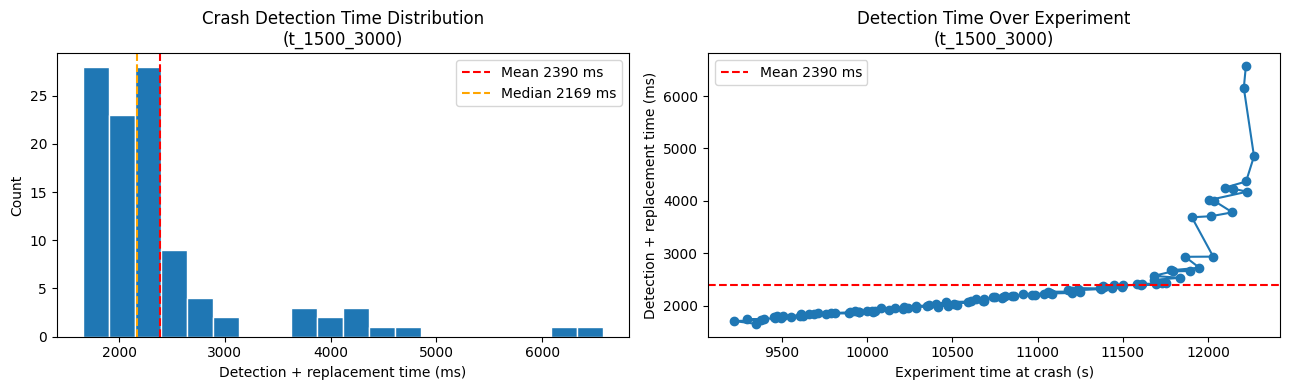

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Histogram ---
ax = axes[0]
ax.hist(results["detection_ms"], bins=20, edgecolor="white")
ax.axvline(results["detection_ms"].mean(),   color="red",    linestyle="--", label=f"Mean {results['detection_ms'].mean():.0f} ms")
ax.axvline(results["detection_ms"].median(), color="orange", linestyle="--", label=f"Median {results['detection_ms'].median():.0f} ms")
ax.set_xlabel("Detection + replacement time (ms)")
ax.set_ylabel("Count")
ax.set_title(f"Crash Detection Time Distribution\n({NAME})")
ax.legend()

# --- Over time (per crash) ---
ax = axes[1]
ax.plot(results["t_last_heartbeat"], sorted(results["detection_ms"]), marker="o")
ax.axhline(results["detection_ms"].mean(), color="red", linestyle="--", label=f"Mean {results['detection_ms'].mean():.0f} ms")
ax.set_xlabel("Experiment time at crash (s)")
ax.set_ylabel("Detection + replacement time (ms)")
ax.set_title(f"Detection Time Over Experiment\n({NAME})")
ax.legend()

plt.tight_layout()
plt.show()

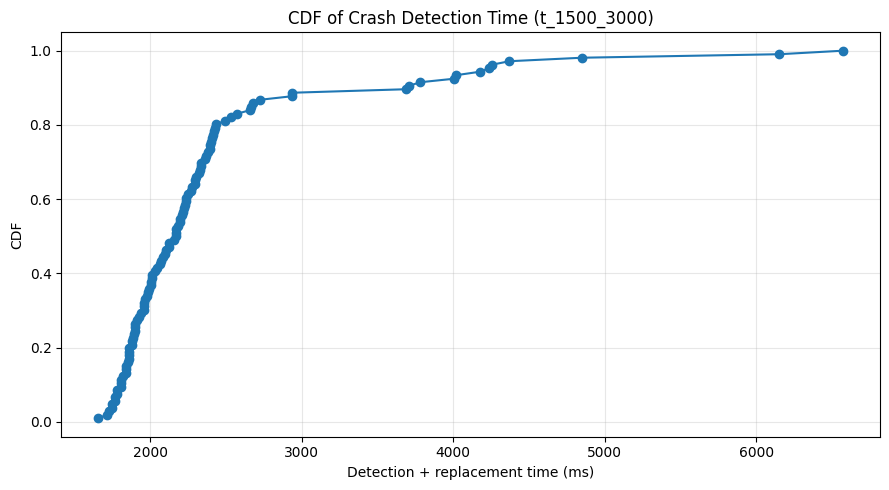

In [12]:
sorted_ms = np.sort(results["detection_ms"])
cdf = np.arange(1, len(sorted_ms) + 1) / len(sorted_ms)

plt.plot(sorted_ms, cdf, marker="o")
plt.xlabel("Detection + replacement time (ms)")
plt.ylabel("CDF")
plt.title(f"CDF of Crash Detection Time ({NAME})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()